### Feature extraction + XGBoost modelling, in a pipeline

Running 5-fold out-of-fold cross-validation...

Fold 1: Train Acc = 1.0000, Test Acc = 0.9410
Fold 2: Train Acc = 1.0000, Test Acc = 0.9829
Fold 3: Train Acc = 1.0000, Test Acc = 0.9636
Fold 4: Train Acc = 0.9999, Test Acc = 0.9594
Fold 5: Train Acc = 1.0000, Test Acc = 0.9187
----------------------------------------
Average Test Accuracy: 0.9531 (+/- 0.0218)
Logged run to ../dataset/experiment_logs.jsonl (JSONL)

Top 20 Most Important Features:
fBodyAcc-bandsEnergy()-1,8.2      0.061558
tGravityAcc-mean()-X              0.056975
fBodyAcc-bandsEnergy()-9,16.1     0.039481
fBodyAcc-skewness()-X             0.038285
fBodyAcc-bandsEnergy()-1,8.1      0.030207
fBodyAcc-bandsEnergy()-41,48      0.024346
fBodyAcc-bandsEnergy()-17,24.1    0.023615
tBodyAcc-std()-X                  0.022858
tBodyGyro-energy()-Z              0.022286
fBodyBodyGyroMag-maxInds          0.021542
tBodyGyro-max()-X                 0.020312
fBodyGyro-maxInds-X               0.020159
tGravityAcc-mean()-Y              

/var/folders/s2/_qxs1d_57r18ktd8jtkpm0sw0000gn/T/ipykernel_63801/1461063832.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_fi.head(20).values, y=mean_fi.head(20).index, palette='viridis')


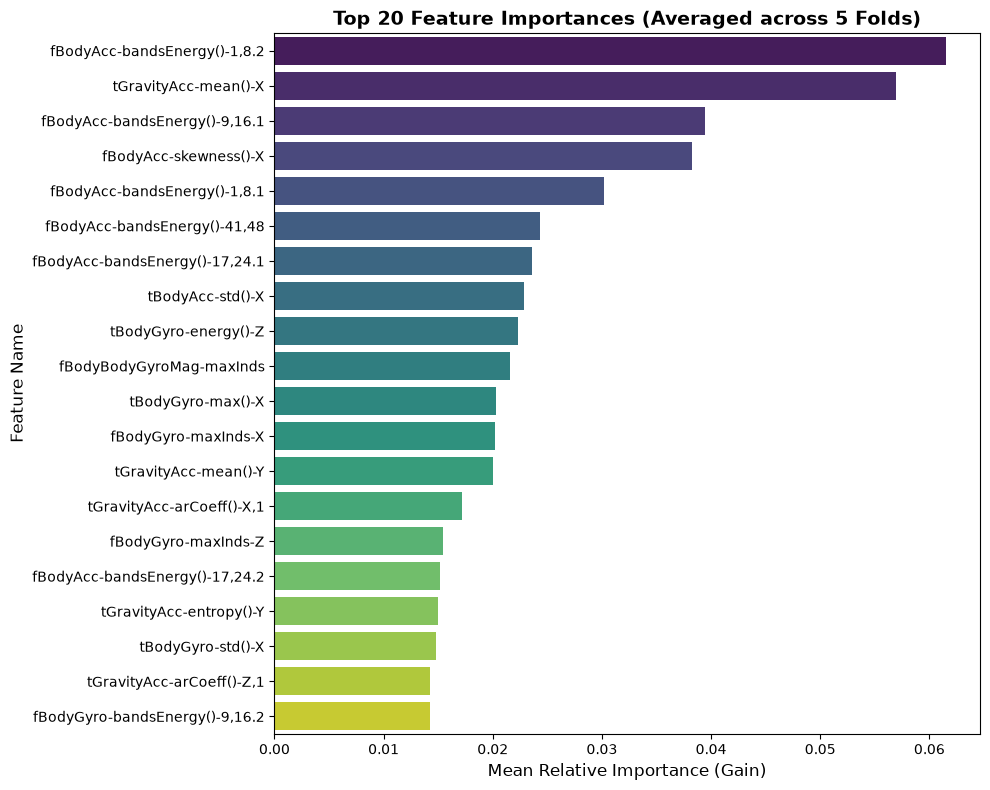

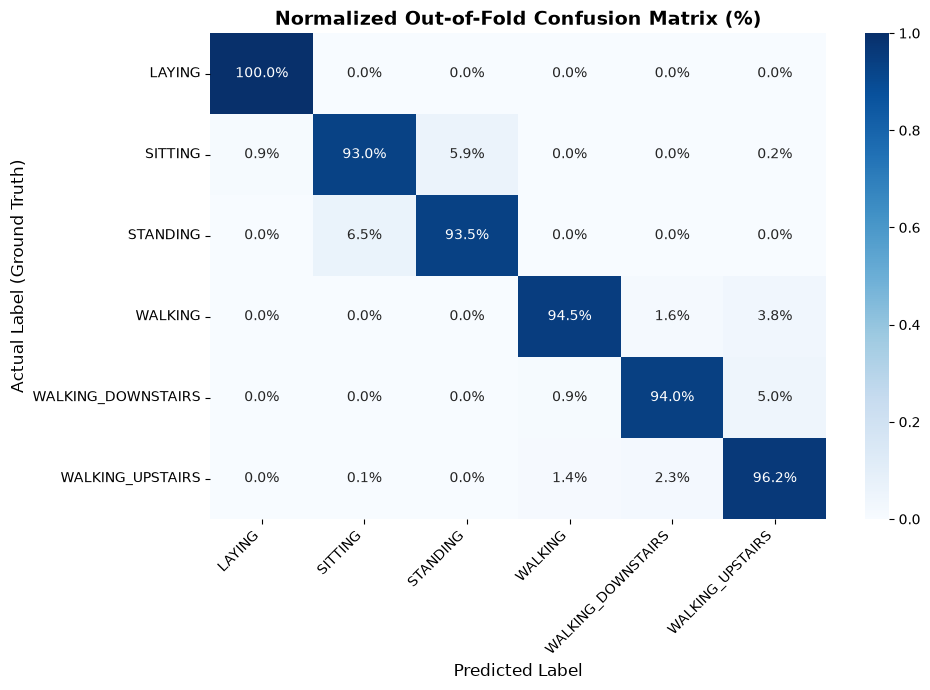

In [ ]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb

note_for_docs = "30% test, 70% train. 5 fold GroupKFold."

def log_experiment(params, accuracy, cm_normalized, labels, filepath="experiment_logs.jsonl", mode="jsonl"):
    """
    Logs hyperparameter tuning runs to either JSON Lines or CSV.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if mode == "jsonl":
        cm_dict = {
            actual: {pred: round(float(cm_normalized[i, j] * 100), 2) 
                     for j, pred in enumerate(labels)}
            for i, actual in enumerate(labels)
        }
        
        entry = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "hyperparameters": params,
            "confusion_matrix_pct": cm_dict,
            "note": note_for_docs
        }
        
        os.makedirs(os.path.dirname(filepath), exist_ok=True) if os.path.dirname(filepath) else None
        with open(filepath, "a") as f:
            f.write(json.dumps(entry) + "\n")
        print(f"Logged run to {filepath} (JSONL)")

    elif mode == "csv":
        row = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            **{f"param_{k}": v for k, v in params.items()}
        }
        
        for i, actual in enumerate(labels):
            for j, pred in enumerate(labels):
                col_name = f"cm_{actual}_{pred}"
                row[col_name] = round(float(cm_normalized[i, j] * 100), 2)
        
        df_row = pd.DataFrame([row])
        file_exists = os.path.isfile(filepath)
        df_row.to_csv(filepath, mode="a", index=False, header=not file_exists)
        print(f"Logged run to {filepath} (CSV)")


# 1. Pipeline-Safe Correlation Filter (Index-based for transformer safety)
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.to_drop_indices_ = []

    def fit(self, X, y=None):
        df_x = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        corr_matrix = df_x.corr().abs()
        
        upper_tri = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        
        self.to_drop_indices_ = [
            i for i, col in enumerate(upper_tri.columns) 
            if any(upper_tri[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(X.columns[self.to_drop_indices_], axis=1).values
        return np.delete(X, self.to_drop_indices_, axis=1)


def get_pipeline_feature_names(pipeline, initial_feature_names):
    """
    Tracks surviving feature names through VarianceThreshold and CorrelationFilter.
    """
    current_features = list(initial_feature_names)
    
    # 1. Track VarianceThreshold
    if 'variance' in pipeline.named_steps:
        vt = pipeline.named_steps['variance']
        current_features = [f for f, keep in zip(current_features, vt.get_support()) if keep]
        
    # 2. Track CorrelationFilter
    if 'correlation' in pipeline.named_steps:
        cf = pipeline.named_steps['correlation']
        current_features = [f for i, f in enumerate(current_features) if i not in cf.to_drop_indices_]
        
    return current_features


# 2. Load and Prepare Data
df = pd.read_csv('../dataset/full_wo_fft.csv')

X = df.drop(columns=['Activity', 'subject'])
groups = df['subject']

le = LabelEncoder()
y = le.fit_transform(df['Activity'])
labels = le.classes_

param = {
    'learning_rate': 0.1,
    'max_depth': 6,
    'n_estimators': 200,
    'subsample': 0.6,
    'colsample_bytree': 0.7,
    'min_child_weight': 7,
    'reg_lambda': 5.0,
    'reg_alpha': 0,
    'gamma': 0.2,
    'eval_metric': 'mlogloss',
    'random_state': 69
}

# 3. Define the Pipeline
pipeline = Pipeline([
    ('variance', VarianceThreshold(threshold=0.01)),
    ('correlation', CorrelationFilter(threshold=0.95)),
    ('xgb', xgb.XGBClassifier(**param))
])

# 4. Out-of-Fold Validation Loop (GroupKFold for non-overlapping subjects)
gkf = GroupKFold(n_splits=5)

y_true_all = []
y_pred_all = []
test_scores = []
train_scores = []

# Store feature importances across all folds
fold_feature_importances = []

print("Running 5-fold out-of-fold cross-validation...\n")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit pipeline ONLY on train split
    pipeline.fit(X_train, y_train)
    
    # Evaluate
    train_acc = accuracy_score(y_train, pipeline.predict(X_train))
    preds = pipeline.predict(X_test)
    test_acc = accuracy_score(y_test, preds)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    # Accumulate out-of-fold test predictions
    y_true_all.extend(y_test)
    y_pred_all.extend(preds)
    
    # Extract Feature Importances for current fold
    surviving_features = get_pipeline_feature_names(pipeline, X.columns)
    model = pipeline.named_steps['xgb']
    
    # Gain-based importance (or change to model.get_booster().get_score(importance_type='weight') for F-score / splits)
    importances = model.feature_importances_
    fold_fi = pd.Series(importances, index=surviving_features)
    fold_feature_importances.append(fold_fi)
    
    print(f"Fold {fold+1}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

mean_test_acc = np.mean(test_scores)
std_test_acc = np.std(test_scores)

print("-" * 40)
print(f"Average Test Accuracy: {mean_test_acc:.4f} (+/- {std_test_acc:.4f})")

# 5. Calculate Out-of-Fold Confusion Matrix
cm_normalized = confusion_matrix(y_true_all, y_pred_all, normalize='true')

# 6. Log Experiment
log_experiment(
    params=param,
    accuracy=mean_test_acc,
    cm_normalized=cm_normalized,
    labels=labels,
    filepath="../dataset/experiment_logs.jsonl",
    mode="jsonl"
)

# 7. Aggregate and Output Feature Importances
df_fi = pd.concat(fold_feature_importances, axis=1).fillna(0)
mean_fi = df_fi.mean(axis=1).sort_values(ascending=False)

print("\nTop 20 Most Important Features:")
print(mean_fi.head(20))

# 8. Plot Top Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x=mean_fi.head(20).values, y=mean_fi.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (Averaged across 5 Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Relative Importance (Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

# 9. Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Out-of-Fold Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
# 1. Define the hyperparameter search space
# Use 'step_name__parameter_name' syntax to target pipeline steps
param_distributions = {
    # XGBoost Regularization & Tree Structure
    'xgb__n_estimators': [100, 200, 300, 500],
    'xgb__max_depth': [2, 3, 4, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.7, 0.8],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8],
    'xgb__min_child_weight': [3, 5, 7, 10],
    'xgb__gamma': [0, 0.1, 0.2, 0.5],          # Minimum loss reduction for split
    'xgb__reg_alpha': [0, 0.1, 1.0],            # L1 regularization
    'xgb__reg_lambda': [0.1, 1.0, 5.0]          # L2 regularization
}

# 2. Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,             # Evaluates 30 random parameter configurations
    scoring='f1_macro',  # Macro-averaged F1 score (higher is better)
    cv=gss,                # Uses your 5-fold GroupShuffleSplit
    return_train_score=True,
    random_state=69,
    n_jobs=-1
)

# 3. Fit search across subjects
search.fit(X, y, groups=groups)

# 4. View Best Parameters & Results
print("Best Hyperparameters:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV Test Accuracy: {search.best_score_:.4f}")

NameError: name 'gss' is not defined